**Step 1: Load data.** Using the full dataset (not the regression-filtered one): small and high-spending districts are kept because they may be meaningful archetypes, not noise.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('../datasets/district_data_full.csv',dtype={'LEAID': str,'FIPST':str,'SCHLEV':str})
print(df.shape)

(12768, 21)


**Step 2: Select features and scale.** The five features are spending, poverty, math proficiency, reading proficiency, and enrollment. Standardization is required because K-means is distance-based and raw dollar values would otherwise dominate percentage measures.

In [2]:
cluster_features = ['per_pupil_exp', 'poverty_rate', 'PCTPROF_MTH_clean', 'PCTPROF_RLA_clean', 'MEMBERSCH']

df_cluster = df.dropna(subset=cluster_features).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_features])

print(f"Rows used for clustering: {df_cluster.shape[0]}")

Rows used for clustering: 12768


**Step 3: Elbow method.** The plot has a gradual curve rather than a sharp bend. A soft elbow suggests k=4, but the result is ambiguous and needs independent validation.

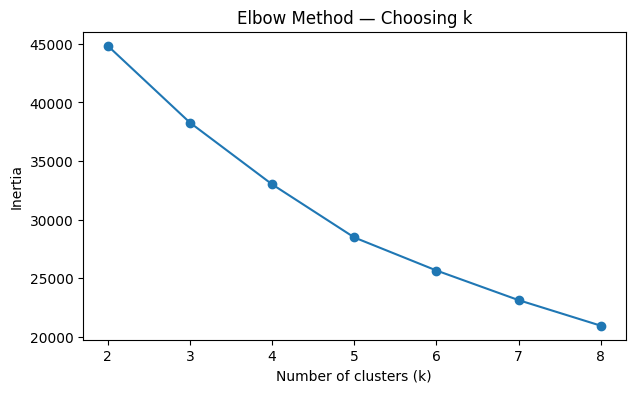

In [3]:
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choosing k')
plt.show()

**Step 4: Validate k with silhouette score.** k=3 (0.321) outperforms k=4 (0.236). **Decision: use k=3**, because silhouette score directly evaluates within-cluster consistency and separation rather than relying on a visual estimate.

In [4]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: silhouette score = {score:.3f}")

k=2: silhouette score = 0.317
k=3: silhouette score = 0.321
k=4: silhouette score = 0.236
k=5: silhouette score = 0.249
k=6: silhouette score = 0.257


**Step 5: Fit and profile the final model (k=3).** Three archetypes emerge: Cluster 0 is low-poverty and high-performing; Cluster 1 is high-poverty and low-performing; Cluster 2 contains 34 mega-districts, averaging more than 168,000 students and the lowest per-pupil spending—consistent with economies of scale.

In [5]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_profile = df_cluster.groupby('cluster')[cluster_features].mean().round(2)
cluster_profile['count'] = df_cluster['cluster'].value_counts().sort_index()

print(cluster_profile)

         per_pupil_exp  poverty_rate  PCTPROF_MTH_clean  PCTPROF_RLA_clean  \
cluster                                                                      
0             18942.43         10.51              58.73              63.39   
1             15809.47         21.32              32.52              38.38   
2             14180.71         17.77              46.68              48.79   

         MEMBERSCH  count  
cluster                    
0          3459.85   5945  
1          2954.79   6789  
2        168610.68     34  


**Step 6: Visually compare k=3 and k=4.** The k=3 solution shows cleanly separated regions, while three of k=4's four clusters overlap in the same area. This supports the silhouette result: k=4 splits one genuine group into arbitrary sub-groups. **k=3 is confirmed as the final solution.**

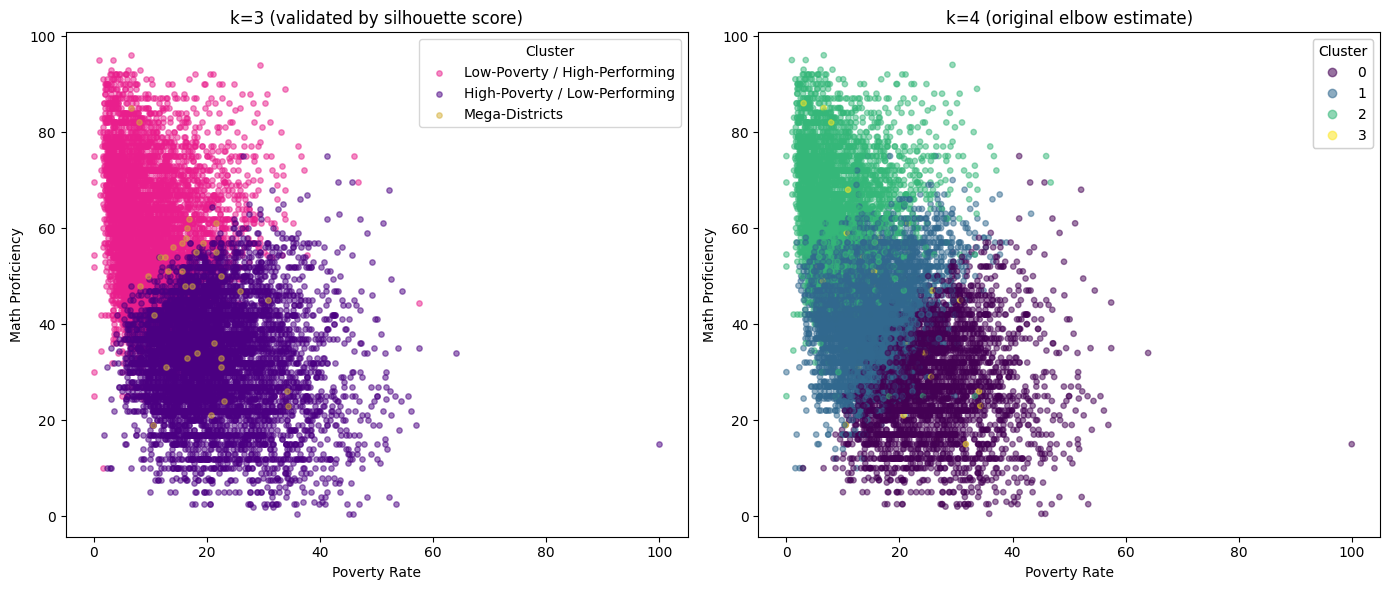

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = kmeans_k3.fit_predict(X_scaled)

kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_k4.fit_predict(X_scaled)

# WHY: KMeans assigns cluster numbers (0,1,2) in arbitrary order — the same 
# archetype could be labeled "0" in one run and "1" in another. Rather than 
# hardcode a mapping, we identify each cluster's identity dynamically by 
# checking its actual average poverty rate and enrollment.

df_temp = df_cluster.copy()
df_temp['label_k3'] = labels_k3

cluster_means = df_temp.groupby('label_k3')[['poverty_rate', 'MEMBERSCH']].mean()

# The mega-district cluster is whichever one has by far the highest average enrollment
mega_id = cluster_means['MEMBERSCH'].idxmax()

# Among the remaining two, the one with higher poverty = high-poverty/low-performing
remaining = cluster_means.drop(mega_id)
high_poverty_id = remaining['poverty_rate'].idxmax()
low_poverty_id = remaining['poverty_rate'].idxmin()

label_map_k3 = {
    low_poverty_id: 'Low-Poverty / High-Performing',
    high_poverty_id: 'High-Poverty / Low-Performing',
    mega_id: 'Mega-Districts',
}
color_map_k3 = {
    low_poverty_id: '#E91E8C',
    high_poverty_id: '#4B0082',
    mega_id: '#D4AF37',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- k=3 panel with named legend ---
for cid, name in label_map_k3.items():
    mask = labels_k3 == cid
    axes[0].scatter(
        df_cluster['poverty_rate'][mask], df_cluster['PCTPROF_MTH_clean'][mask],
        c=color_map_k3[cid], label=name, alpha=0.5, s=15
    )
axes[0].set_title('k=3 (validated by silhouette score)')
axes[0].set_xlabel('Poverty Rate')
axes[0].set_ylabel('Math Proficiency')
axes[0].legend(title="Cluster")

# --- k=4 panel — kept as generic numeric clusters, since this is the 
# rejected alternative shown only for comparison, not a model we're naming ---
scatter2 = axes[1].scatter(
    df_cluster['poverty_rate'], df_cluster['PCTPROF_MTH_clean'],
    c=labels_k4, cmap='viridis', alpha=0.5, s=15
)
axes[1].set_title('k=4 (original elbow estimate)')
axes[1].set_xlabel('Poverty Rate')
axes[1].set_ylabel('Math Proficiency')
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Cluster")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.savefig('k3_vs_k4_comparison.png', dpi=150)
plt.show()

df_cluster['cluster'] = labels_k3
df_cluster['cluster_label'] = df_cluster['cluster'].map(label_map_k3)

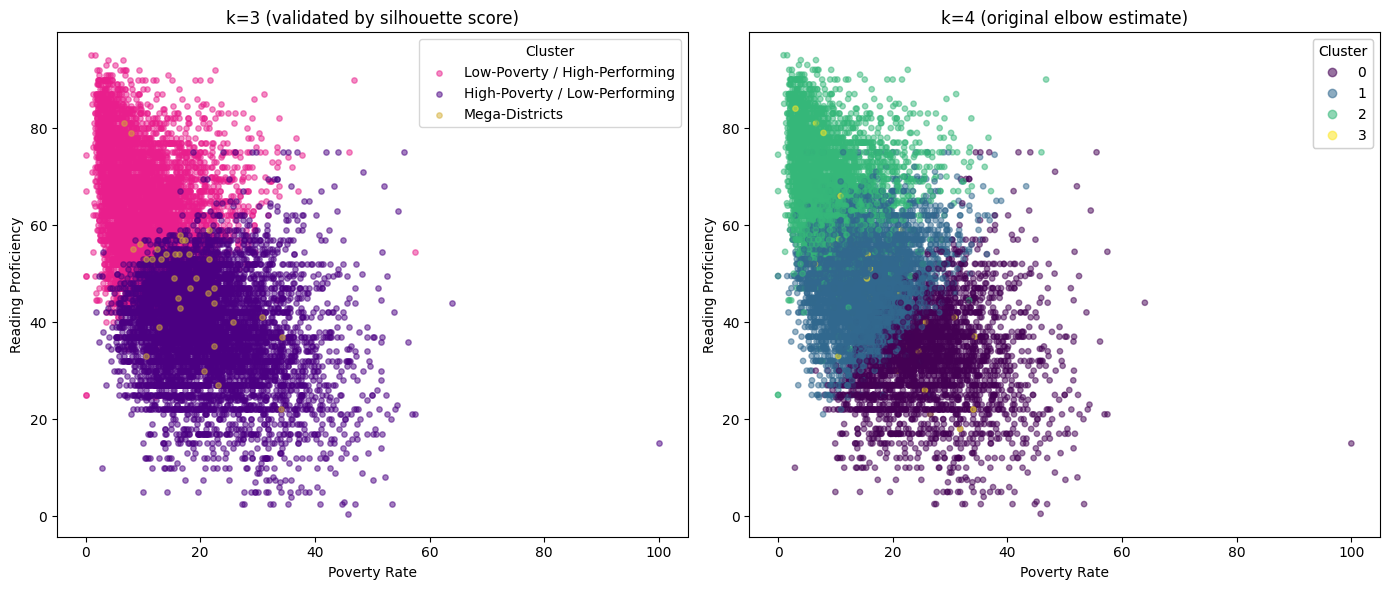

In [7]:


kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = kmeans_k3.fit_predict(X_scaled)

kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_k4.fit_predict(X_scaled)

# WHY: KMeans assigns cluster numbers (0,1,2) in arbitrary order — the same 
# archetype could be labeled "0" in one run and "1" in another. Rather than 
# hardcode a mapping, we identify each cluster's identity dynamically by 
# checking its actual average poverty rate and enrollment.

df_temp = df_cluster.copy()
df_temp['label_k3'] = labels_k3

cluster_means = df_temp.groupby('label_k3')[['poverty_rate', 'MEMBERSCH']].mean()

# The mega-district cluster is whichever one has by far the highest average enrollment
mega_id = cluster_means['MEMBERSCH'].idxmax()

# Among the remaining two, the one with higher poverty = high-poverty/low-performing
remaining = cluster_means.drop(mega_id)
high_poverty_id = remaining['poverty_rate'].idxmax()
low_poverty_id = remaining['poverty_rate'].idxmin()

label_map_k3 = {
    low_poverty_id: 'Low-Poverty / High-Performing',
    high_poverty_id: 'High-Poverty / Low-Performing',
    mega_id: 'Mega-Districts',
}
color_map_k3 = {
    low_poverty_id: '#E91E8C',
    high_poverty_id: '#4B0082',
    mega_id: '#D4AF37',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- k=3 panel with named legend ---
for cid, name in label_map_k3.items():
    mask = labels_k3 == cid
    axes[0].scatter(
        df_cluster['poverty_rate'][mask], df_cluster['PCTPROF_RLA_clean'][mask],
        c=color_map_k3[cid], label=name, alpha=0.5, s=15
    )
axes[0].set_title('k=3 (validated by silhouette score)')
axes[0].set_xlabel('Poverty Rate')
axes[0].set_ylabel('Reading Proficiency')
axes[0].legend(title="Cluster")

# --- k=4 panel — kept as generic numeric clusters, since this is the 
# rejected alternative shown only for comparison, not a model we're naming ---
scatter2 = axes[1].scatter(
    df_cluster['poverty_rate'], df_cluster['PCTPROF_RLA_clean'],
    c=labels_k4, cmap='viridis', alpha=0.5, s=15
)
axes[1].set_title('k=4 (original elbow estimate)')
axes[1].set_xlabel('Poverty Rate')
axes[1].set_ylabel('Reading Proficiency')
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Cluster")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

df_cluster['cluster'] = labels_k3
df_cluster['cluster_label'] = df_cluster['cluster'].map(label_map_k3)

**Robustness check 1: Log-transform enrollment.** Enrollment is strongly right-skewed, so a log-transformed version was tested. Scores fell at every k (for k=3, 0.321 to 0.268). **Decision: retain raw enrollment**—the extreme mega-district values represent meaningful separation rather than distortion.

In [8]:
import numpy as np

df_cluster['log_enrollment'] = np.log1p(df_cluster['MEMBERSCH'])  # log1p handles any zero values safely

cluster_features_log = ['per_pupil_exp', 'poverty_rate', 'PCTPROF_MTH_clean', 'PCTPROF_RLA_clean', 'log_enrollment']
X_scaled_log = scaler.fit_transform(df_cluster[cluster_features_log])

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_log)
    score = silhouette_score(X_scaled_log, labels)
    print(f"k={k}: silhouette score = {score:.3f}")

k=2: silhouette score = 0.276
k=3: silhouette score = 0.268
k=4: silhouette score = 0.203
k=5: silhouette score = 0.205
k=6: silhouette score = 0.198


**Robustness check 2: Per-sample silhouette plot.** This examines individual districts rather than only the average. The small mega-district cluster is cleanly separated, while some districts in Clusters 0 and 1 sit near the poverty/proficiency boundary. **Conclusion: all three clusters are reasonably well formed, with a real transition zone between the two larger archetypes.**

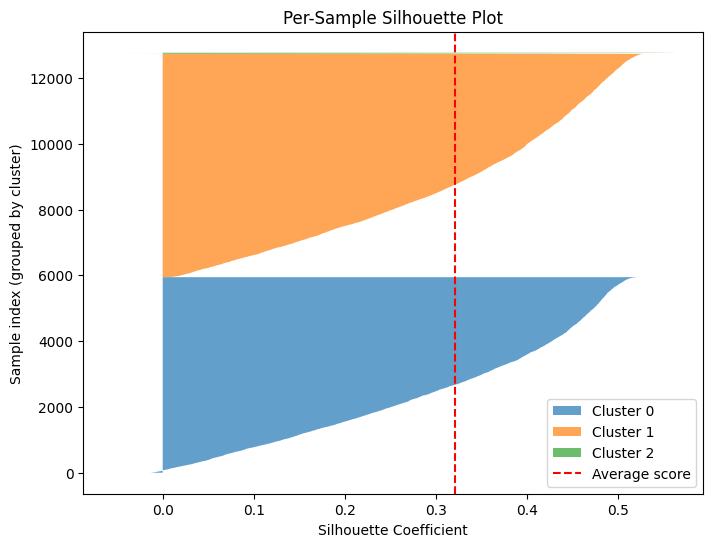

In [9]:
from sklearn.metrics import silhouette_samples

sil_values = silhouette_samples(X_scaled, labels_k3)  # from your k=3 fit
df_cluster['silhouette'] = sil_values

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 0
for c in sorted(df_cluster['cluster'].unique()):
    cluster_sil = np.sort(df_cluster[df_cluster['cluster'] == c]['silhouette'])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7, label=f'Cluster {c}')
    y_lower = y_upper

ax.axvline(x=0.321, color='red', linestyle='--', label='Average score')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Sample index (grouped by cluster)')
ax.set_title('Per-Sample Silhouette Plot')
ax.legend()
plt.show()

**Robustness check 3: Stability across random seeds.** ARI scores range from 0.994 to 1.000 across five random seeds, showing near-identical assignments in every run. **Conclusion: the k=3 solution is highly stable, not a product of one random initialization.**

In [10]:
from sklearn.metrics import adjusted_rand_score

seeds = [0, 1, 42, 100, 2024]
labels_by_seed = []

for seed in seeds:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels_by_seed.append(km.fit_predict(X_scaled))

print("Pairwise agreement between different random seeds:")
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        ari = adjusted_rand_score(labels_by_seed[i], labels_by_seed[j])
        print(f"  Seed {seeds[i]} vs Seed {seeds[j]}: ARI = {ari:.3f}")

Pairwise agreement between different random seeds:
  Seed 0 vs Seed 1: ARI = 0.997
  Seed 0 vs Seed 42: ARI = 0.994
  Seed 0 vs Seed 100: ARI = 0.996
  Seed 0 vs Seed 2024: ARI = 0.998
  Seed 1 vs Seed 42: ARI = 0.997
  Seed 1 vs Seed 100: ARI = 0.998
  Seed 1 vs Seed 2024: ARI = 1.000
  Seed 42 vs Seed 100: ARI = 0.996
  Seed 42 vs Seed 2024: ARI = 0.997
  Seed 100 vs Seed 2024: ARI = 0.998


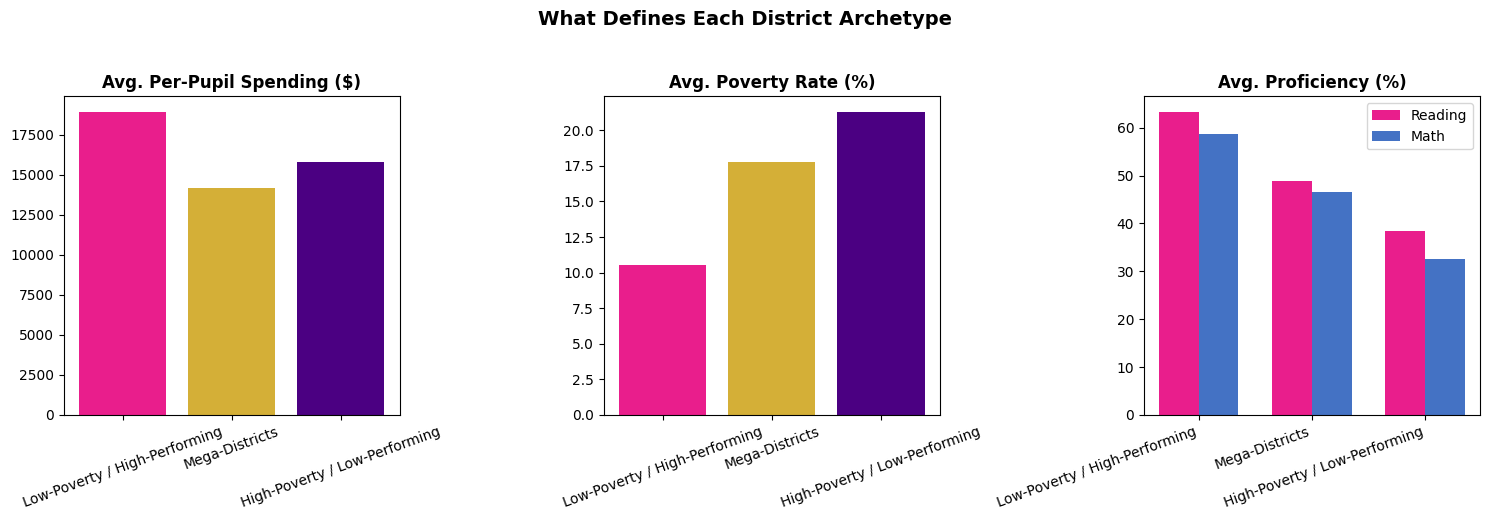

In [11]:
# WHY: Summarizes what actually defines each cluster — average spending, 
# poverty, and proficiency — making the three archetypes legible without 
# needing to read raw cluster statistics.

cluster_summary = df_cluster.groupby('cluster_label')[
    ['per_pupil_exp', 'poverty_rate', 'PCTPROF_MTH_clean', 'PCTPROF_RLA_clean']
].mean().reindex(['Low-Poverty / High-Performing', 'Mega-Districts', 'High-Poverty / Low-Performing'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = ['#E91E8C', '#D4AF37', '#4B0082']

axes[0].bar(cluster_summary.index, cluster_summary['per_pupil_exp'], color=bar_colors)
axes[0].set_title('Avg. Per-Pupil Spending ($)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(cluster_summary.index, cluster_summary['poverty_rate'], color=bar_colors)
axes[1].set_title('Avg. Poverty Rate (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

# WHY: plot Reading and Math as separate, side-by-side bars (not stacked/
# overlapping) using an x-offset, so both are individually visible and 
# directly comparable per cluster.
x = np.arange(len(cluster_summary.index))
width = 0.35

axes[2].bar(x - width/2, cluster_summary['PCTPROF_RLA_clean'], width, color='#E91E8C', label='Reading')
axes[2].bar(x + width/2, cluster_summary['PCTPROF_MTH_clean'], width, color='#4472C4', label='Math')
axes[2].set_title('Avg. Proficiency (%)', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(cluster_summary.index, rotation=20, ha='right')
axes[2].legend()

plt.suptitle('What Defines Each District Archetype', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('cluster_profile_bars.png', dpi=150)
plt.show()

**Final step: Export.** The full dataset, including final k=3 cluster labels and robustness-check fields, is saved for use in Power BI.

In [13]:
df_cluster.to_csv('../datasets/district_data_with_clusters.csv', index=False)
print(f"Saved district_data_with_clusters.csv — {df_cluster.shape[0]} rows, {df_cluster.shape[1]} columns")

Saved district_data_with_clusters.csv — 12768 rows, 25 columns
